<a href="https://colab.research.google.com/github/HussainGit-jpg/BFS_LAB/blob/main/LAB_ASSIGNMENT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#NAME : MUHAMMAD HUSSAIN
#REG_NO : FA24-BCS-121
#COURCE : AI

=== BFS and DFS Results ===
BFS from node 1: [1, 2, 3, 4, 7, 8, 5, 6]
DFS from node 1: [1, 2, 7, 3, 8, 4, 5, 6]


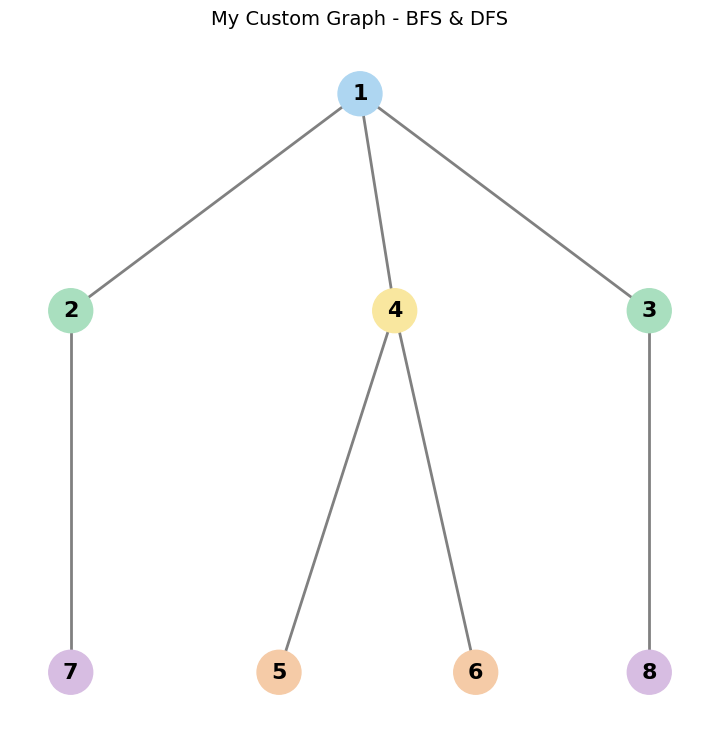

In [9]:
import networkx as nx
import matplotlib.pyplot as plt
from collections import deque

# ---- Your Graph ----
graph = {
    1: [2, 3, 4],
    2: [1, 7],
    3: [1, 8],
    4: [1, 5, 6],
    5: [4],
    6: [4],
    7: [2],
    8: [3]
}

# ---- BFS ----
def bfs(graph, start):
    visited = []
    queue = deque([start])
    seen = set([start])
    while queue:
        node = queue.popleft()
        visited.append(node)
        for neighbor in graph[node]:
            if neighbor not in seen:
                seen.add(neighbor)
                queue.append(neighbor)
    return visited

# ---- DFS ----
def dfs(graph, start):
    visited = []
    stack = [start]
    seen = set()
    while stack:
        node = stack.pop()
        if node not in seen:
            seen.add(node)
            visited.append(node)
            for neighbor in reversed(graph[node]):
                stack.append(neighbor)
    return visited

# ---- Print Results ----
print("=== BFS and DFS Results ===")
print("BFS from node 1:", bfs(graph, 1))
print("DFS from node 1:", dfs(graph, 1))

# ---- Draw the Graph ----
G = nx.Graph()
for node, neighbors in graph.items():
    for neighbor in neighbors:
        G.add_edge(node, neighbor)


positions = {
    1: (2.5, 4.0),   # top center
    2: (0.0, 2.5),   # left middle
    3: (5.0, 2.5),   # right middle
    4: (2.8, 2.5),   # center
    5: (1.8, 0.0),   # bottom center-left
    6: (3.5, 0.0),   # bottom center-right
    7: (0.0, 0.0),   # bottom left
    8: (5.0, 0.0),   # bottom right
}

colors = {
    1: '#AED6F1',   # blue  - root/hub
    2: '#A9DFBF',   # green
    3: '#A9DFBF',   # green
    4: '#F9E79F',   # yellow - connector
    5: '#F5CBA7',   # orange
    6: '#F5CBA7',   # orange
    7: '#D7BDE2',   # purple
    8: '#D7BDE2',   # purple
}
node_colors = [colors[n] for n in G.nodes()]

plt.figure(figsize=(7, 7))
nx.draw(
    G,
    pos=positions,
    with_labels=True,
    node_color=node_colors,
    node_size=1000,
    font_size=16,
    font_weight='bold',
    edge_color='gray',
    width=2
)
plt.title("My Custom Graph - BFS & DFS", fontsize=14)
plt.show()

# DFS GRAPH

=== DFS Step by Step ===
Visiting node: 1  |  Stack now: []
Visiting node: 2  |  Stack now: [4, 3]
Visiting node: 7  |  Stack now: [4, 3]
Visiting node: 3  |  Stack now: [4]
Visiting node: 8  |  Stack now: [4]
Visiting node: 4  |  Stack now: []
Visiting node: 5  |  Stack now: [6]
Visiting node: 6  |  Stack now: []

DFS Final Order: [1, 2, 7, 3, 8, 4, 5, 6]


/tmp/ipykernel_3270/2894680548.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


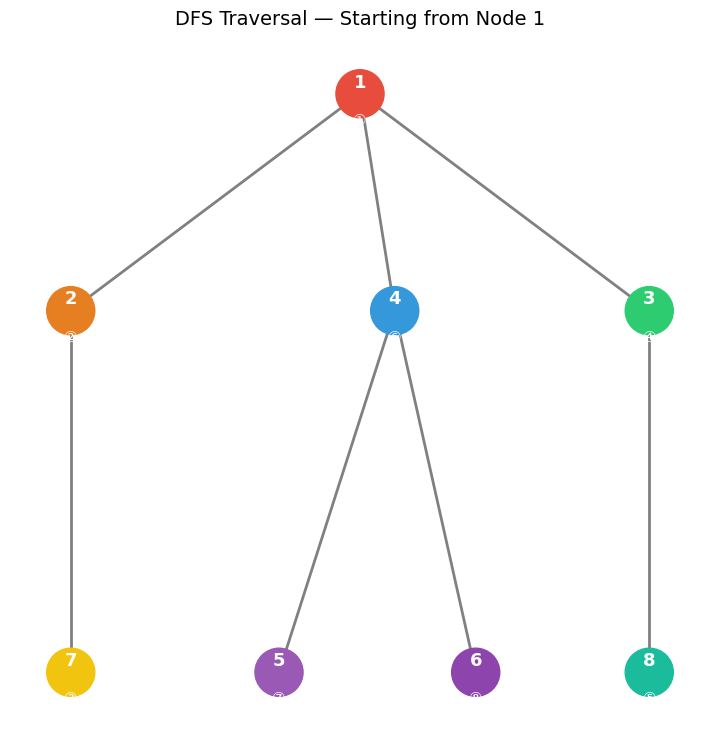

In [10]:
import networkx as nx
import matplotlib.pyplot as plt

# ---- Your Graph ----
graph = {
    1: [2, 3, 4],
    2: [1, 7],
    3: [1, 8],
    4: [1, 5, 6],
    5: [4],
    6: [4],
    7: [2],
    8: [3]
}

# ---- DFS Function ----
def dfs(graph, start):
    visited = []
    stack = [start]
    seen = set()

    print("=== DFS Step by Step ===")

    while stack:
        node = stack.pop()            # take from TOP of stack
        if node not in seen:
            seen.add(node)
            visited.append(node)
            print(f"Visiting node: {node}  |  Stack now: {stack}")
            for neighbor in reversed(graph[node]):  # reversed to go left first
                if neighbor not in seen:
                    stack.append(neighbor)

    return visited

# ---- Run DFS ----
result = dfs(graph, 1)
print("\nDFS Final Order:", result)

# ---- Draw the Graph with DFS order ----
G = nx.Graph()
for node, neighbors in graph.items():
    for neighbor in neighbors:
        G.add_edge(node, neighbor)

# Fixed positions matching your graph layout
positions = {
    1: (2.5, 4.0),
    2: (0.0, 2.5),
    3: (5.0, 2.5),
    4: (2.8, 2.5),
    5: (1.8, 0.0),
    6: (3.5, 0.0),
    7: (0.0, 0.0),
    8: (5.0, 0.0),
}

# DFS visit order labels to show on nodes
dfs_order = {1:'①', 2:'②', 3:'④', 4:'⑥', 5:'⑦', 6:'⑧', 7:'③', 8:'⑤'}

# Color nodes by DFS visit order
# darker = visited earlier
colors = {
    1: '#E74C3C',   # red   - visited 1st
    2: '#E67E22',   # orange - visited 2nd
    7: '#F1C40F',   # yellow - visited 3rd
    3: '#2ECC71',   # green - visited 4th
    8: '#1ABC9C',   # teal  - visited 5th
    4: '#3498DB',   # blue  - visited 6th
    5: '#9B59B6',   # purple - visited 7th
    6: '#8E44AD',   # dark purple - visited 8th
}
node_colors = [colors[n] for n in G.nodes()]

# Draw
plt.figure(figsize=(7, 7))
nx.draw(
    G,
    pos=positions,
    with_labels=False,        # we draw labels manually
    node_color=node_colors,
    node_size=1200,
    font_size=14,
    edge_color='gray',
    width=2
)

# Add node number + DFS order as labels
for node, (x, y) in positions.items():
    plt.text(x, y+0.08, str(node),
             ha='center', va='center',
             fontsize=13, fontweight='bold', color='white')
    plt.text(x, y-0.18, dfs_order[node],
             ha='center', va='center',
             fontsize=11, color='white')

plt.title("DFS Traversal — Starting from Node 1", fontsize=14)
plt.tight_layout()
plt.show()

#TASK_2
1. Generate random and unique numbers of ranges 1000,40,000,80,000,200,000 and
1,000,000. So now you have 5 sets of inputs, build the tree for each sets (each set has its
own list)
2. Apply BFS and DFS on each sets and calculate the time taken for the execution to find
that goal through BFS and DFS.
3. Goal should be lis[total_len – 220]
4. Make a data frame for your results as shown below.
5. Finally plot the bar chart of the time taken by each search for example (on X-axis the data
will be 1000,40,000,80,000,200,000 and 1,000,000.) and on the Y axis the data will be
the seconds it took while searching.

 List of 1000 generated  | First 3: [6066, 1002, 1060] | Last 3: [2601, 6529, 655]
 List of 40000 generated  | First 3: [18070, 81695, 360318] | Last 3: [31076, 300745, 4886]
 List of 80000 generated  | First 3: [432968, 170917, 428210] | Last 3: [542615, 193819, 666233]
 List of 200000 generated  | First 3: [1182532, 1277542, 1215303] | Last 3: [1512794, 588462, 891274]
 List of 1000000 generated  | First 3: [4040624, 1980943, 1341050] | Last 3: [2409516, 9578892, 7036623]

 Size:     1000 | total_len: 1000 | goal = lis[780] = 8893
 Size:    40000 | total_len: 40000 | goal = lis[39780] = 298402
 Size:    80000 | total_len: 80000 | goal = lis[79780] = 508635
 Size:   200000 | total_len: 200000 | goal = lis[199780] = 1158388
 Size:  1000000 | total_len: 1000000 | goal = lis[999780] = 8680573

                  RESULTS DATAFRAME
 Tree Size  Goal Value  BFS Time (seconds)  DFS Time (seconds)
      1000        8893            0.000123            0.000104
     40000      298402            0

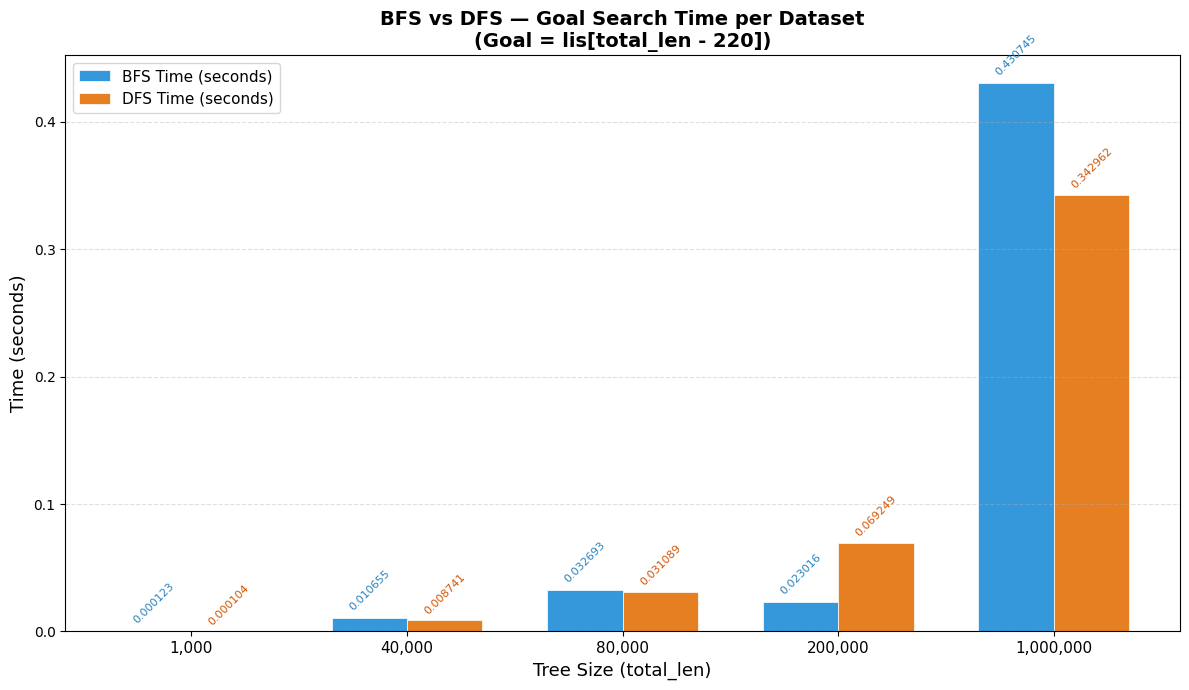

In [11]:
import random
import time
import pandas as pd
import matplotlib.pyplot as plt
from collections import deque

# ================================================
# STEP 1: Binary Search Tree
# ================================================

class Node:
    def __init__(self, value):
        self.value = value
        self.left  = None
        self.right = None

class BST:
    def __init__(self):
        self.root = None

    def insert(self, value):
        if self.root is None:
            self.root = Node(value)
        else:
            self._insert(self.root, value)

    def _insert(self, node, value):
        if value < node.value:
            if node.left is None:
                node.left = Node(value)
            else:
                self._insert(node.left, value)
        else:
            if node.right is None:
                node.right = Node(value)
            else:
                self._insert(node.right, value)

# ================================================
# STEP 2: BFS Search (finds GOAL)
# ================================================

def bfs_search(root, goal):
    if root is None:
        return False
    queue = deque([root])
    while queue:
        node = queue.popleft()
        if node.value == goal:
            return True
        if node.left:
            queue.append(node.left)
        if node.right:
            queue.append(node.right)
    return False

# ================================================
# STEP 3: DFS Search (finds GOAL)
# ================================================

def dfs_search(root, goal):
    if root is None:
        return False
    stack = [root]
    while stack:
        node = stack.pop()
        if node.value == goal:
            return True
        if node.right:
            stack.append(node.right)
        if node.left:
            stack.append(node.left)
    return False

# ================================================
# STEP 4: Generate 5 separate lists
#         Each list is unique and independent
# ================================================

sizes = [1000, 40000, 80000, 200000, 1000000]

# Each size gets its OWN separate list
all_lists = {}
for size in sizes:
    all_lists[size] = random.sample(range(1, size * 10), size)
    print(f" List of {size} generated  | First 3: {all_lists[size][:3]} | Last 3: {all_lists[size][-3:]}")

print()

# ================================================
# STEP 5: Build tree for each list
#         Find goal = lis[total_len - 220]
#         Measure BFS and DFS time in seconds
# ================================================

results = []

for size in sizes:

    # Get the list for this size
    lis = all_lists[size]

    #  EXACT goal formula from assignment
    total_len = len(lis)
    goal      = lis[total_len - 220]

    print(f" Size: {size:>8} | total_len: {total_len} | goal = lis[{total_len-220}] = {goal}")

    # Build BST from this list
    tree = BST()
    for num in lis:
        tree.insert(num)

    # --- BFS time ---
    start    = time.perf_counter()
    bfs_search(tree.root, goal)
    bfs_time = time.perf_counter() - start   # in seconds

    # --- DFS time ---
    start    = time.perf_counter()
    dfs_search(tree.root, goal)
    dfs_time = time.perf_counter() - start   # in seconds

    results.append({
        'Tree Size'          : size,
        'Goal Value'         : goal,
        'BFS Time (seconds)' : round(bfs_time, 6),
        'DFS Time (seconds)' : round(dfs_time, 6)
    })

# ================================================
# STEP 6: DataFrame — exactly as assignment shows
# ================================================

df = pd.DataFrame(results)

print()
print("=" * 62)
print("                  RESULTS DATAFRAME")
print("=" * 62)
print(df.to_string(index=False))
print("=" * 62)

# ================================================
# STEP 7: Bar Chart
# X axis = Tree sizes
# Y axis = Time in seconds
# ================================================

bfs_times = df['BFS Time (seconds)'].tolist()
dfs_times = df['DFS Time (seconds)'].tolist()
x_labels  = ['1,000', '40,000', '80,000', '200,000', '1,000,000']

x     = range(len(sizes))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 7))

bars1 = ax.bar(
    [i - width/2 for i in x],
    bfs_times,
    width,
    label='BFS Time (seconds)',
    color='#3498DB',
    edgecolor='white',
    linewidth=0.5
)

bars2 = ax.bar(
    [i + width/2 for i in x],
    dfs_times,
    width,
    label='DFS Time (seconds)',
    color='#E67E22',
    edgecolor='white',
    linewidth=0.5
)

# Value labels on top of every bar
for bar in bars1:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(bfs_times) * 0.01,
        f'{bar.get_height():.6f}',
        ha='center', va='bottom',
        fontsize=8, color='#2980B9', rotation=45
    )

for bar in bars2:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(dfs_times) * 0.01,
        f'{bar.get_height():.6f}',
        ha='center', va='bottom',
        fontsize=8, color='#D35400', rotation=45
    )

# Axis labels and title
ax.set_xticks(list(x))
ax.set_xticklabels(x_labels, fontsize=11)
ax.set_xlabel('Tree Size (total_len)',  fontsize=13)
ax.set_ylabel('Time (seconds)',         fontsize=13)
ax.set_title(
    'BFS vs DFS — Goal Search Time per Dataset\n(Goal = lis[total_len - 220])',
    fontsize=14, fontweight='bold'
)

ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

#Task_3
Imagine you're a tourist in Pakistan, and you want to travel from Islamabad to Karachi. You
want to find the shortest route in terms of the number of cities you need to travel through. The
cities are connected through highways, and your goal is to find the shortest path using BFS.
Cities and Their Connections (Graph):
You will use the following cities and their connections for this scenario:
• Islamabad is connected to Rawalpindi, Lahore, and Peshawar.
• Rawalpindi is connected to Islamabad, Peshawar, and Quetta.
• Peshawar is connected to Islamabad, Rawalpindi, and Quetta.
• Lahore is connected to Islamabad, Multan, and Quetta.
• Multan is connected to Lahore, Karachi, and Quetta.
• Quetta is connected to Rawalpindi, Peshawar, Multan, and Karachi.
• Karachi is connected to Multan and Quetta.


 Finding shortest path from Islamabad to Karachi...

       BFS STEP BY STEP TRAVERSAL
Step 1: Visiting --> Islamabad
         Path so far: Islamabad

Step 2: Visiting --> Rawalpindi
         Path so far: Islamabad → Rawalpindi

Step 3: Visiting --> Lahore
         Path so far: Islamabad → Lahore

Step 4: Visiting --> Peshawar
         Path so far: Islamabad → Peshawar

Step 5: Visiting --> Quetta
         Path so far: Islamabad → Rawalpindi → Quetta

Step 6: Visiting --> Multan
         Path so far: Islamabad → Lahore → Multan

Step 7: Visiting --> Karachi
         Path so far: Islamabad → Rawalpindi → Quetta → Karachi

 GOAL REACHED: Karachi

 Shortest Path Found:
   Islamabad → Rawalpindi → Quetta → Karachi

 Total cities visited : 4
  Total hops (edges)   : 3


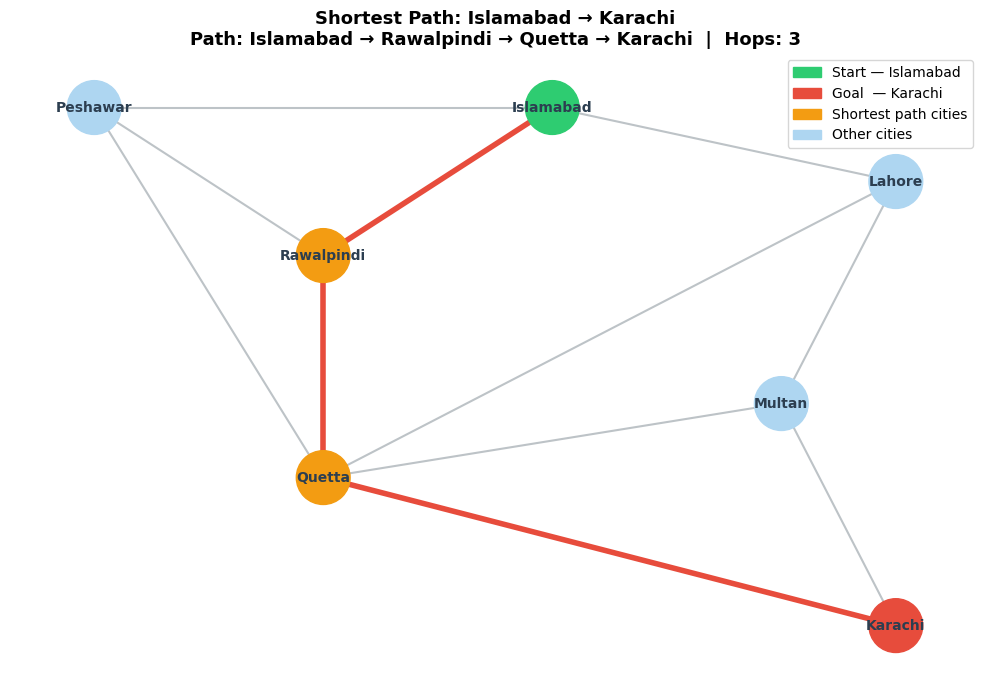

In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
from collections import deque

# ================================================
# STEP 1: Build the City Graph
# ================================================

graph = {
    'Islamabad'  : ['Rawalpindi', 'Lahore', 'Peshawar'],
    'Rawalpindi' : ['Islamabad', 'Peshawar', 'Quetta'],
    'Peshawar'   : ['Islamabad', 'Rawalpindi', 'Quetta'],
    'Lahore'     : ['Islamabad', 'Multan', 'Quetta'],
    'Multan'     : ['Lahore', 'Karachi', 'Quetta'],
    'Quetta'     : ['Rawalpindi', 'Peshawar', 'Multan', 'Karachi'],
    'Karachi'    : ['Multan', 'Quetta']
}

# ================================================
# STEP 2: BFS — Find Shortest Path
# ================================================

def bfs_shortest_path(graph, start, goal):

    # Queue stores (current_city, path_so_far)
    queue   = deque([(start, [start])])
    visited = set([start])

    print("=" * 55)
    print("       BFS STEP BY STEP TRAVERSAL")
    print("=" * 55)
    step = 1

    while queue:

        city, path = queue.popleft()

        print(f"Step {step}: Visiting --> {city}")
        print(f"         Path so far: {' → '.join(path)}")
        print()
        step += 1

        #  Goal reached!
        if city == goal:
            print("=" * 55)
            print(f" GOAL REACHED: {goal}")
            print("=" * 55)
            return path

        # Add all unvisited neighbors to queue
        for neighbor in graph[city]:
            if neighbor not in visited:
                visited.add(neighbor)
                queue.append((neighbor, path + [neighbor]))

    return None   # no path found

# ================================================
# STEP 3: Run BFS from Islamabad to Karachi
# ================================================

start = 'Islamabad'
goal  = 'Karachi'

print(f"\n Finding shortest path from {start} to {goal}...\n")

shortest_path = bfs_shortest_path(graph, start, goal)

print(f"\n Shortest Path Found:")
print(f"   {' → '.join(shortest_path)}")
print(f"\n Total cities visited : {len(shortest_path)}")
print(f"  Total hops (edges)   : {len(shortest_path) - 1}")

# ================================================
# STEP 4: Draw the Graph
# Highlight the shortest path in color
# ================================================

G = nx.Graph()

# Add all edges
for city, neighbors in graph.items():
    for neighbor in neighbors:
        G.add_edge(city, neighbor)

# Fixed positions (roughly matching Pakistan geography)
positions = {
    'Peshawar'   : (0.0, 3.5),
    'Islamabad'  : (2.0, 3.5),
    'Rawalpindi' : (1.0, 2.5),
    'Lahore'     : (3.5, 3.0),
    'Quetta'     : (1.0, 1.0),
    'Multan'     : (3.0, 1.5),
    'Karachi'    : (3.5, 0.0),
}

# Build shortest path edges
path_edges = []
for i in range(len(shortest_path) - 1):
    path_edges.append((shortest_path[i], shortest_path[i+1]))

# All other edges
other_edges = [e for e in G.edges() if e not in path_edges
               and (e[1], e[0]) not in path_edges]

# Node colors
node_colors = []
for node in G.nodes():
    if node == start:
        node_colors.append('#2ECC71')    # green  = start
    elif node == goal:
        node_colors.append('#E74C3C')    # red    = goal
    elif node in shortest_path:
        node_colors.append('#F39C12')    # orange = on path
    else:
        node_colors.append('#AED6F1')    # blue   = not on path

plt.figure(figsize=(10, 7))

# Draw normal edges
nx.draw_networkx_edges(G, positions,
                       edgelist=other_edges,
                       width=1.5,
                       edge_color='#BDC3C7')

# Draw shortest path edges (thick + colored)
nx.draw_networkx_edges(G, positions,
                       edgelist=path_edges,
                       width=4.0,
                       edge_color='#E74C3C',
                       style='solid')

# Draw nodes
nx.draw_networkx_nodes(G, positions,
                       node_color=node_colors,
                       node_size=1500)

# Draw labels
nx.draw_networkx_labels(G, positions,
                        font_size=10,
                        font_weight='bold',
                        font_color='#2C3E50')

# Legend
legend = [
    mpatches.Patch(color='#2ECC71', label='Start — Islamabad'),
    mpatches.Patch(color='#E74C3C', label='Goal  — Karachi'),
    mpatches.Patch(color='#F39C12', label='Shortest path cities'),
    mpatches.Patch(color='#AED6F1', label='Other cities'),
]
plt.legend(handles=legend, loc='upper right', fontsize=10)

plt.title(
    f'Shortest Path: Islamabad → Karachi\n'
    f'Path: {" → ".join(shortest_path)}  |  Hops: {len(shortest_path)-1}',
    fontsize=13, fontweight='bold'
)

plt.axis('off')
plt.tight_layout()
plt.show()

# Why is this the shortest path?

Path----------------------------------------------Hops---------
HopsIslamabad → Lahore → Multan → Karachi________3Hops__shortest.
Islamabad → Rawalpindi → Quetta → Karachi _______3hops. ______
Islamabad → Lahore → Quetta → Karachi ___________3hops. ____
Islamabad → Peshawar → Quetta → Karachi _________4hops.